In [893]:
from sklearn.linear_model import LogisticRegression

In [894]:
lr = LogisticRegression(
    max_iter=1000
)

In [895]:
from sklearn.model_selection import train_test_split

In [896]:
import pandas as pd

df = pd.read_csv("../data/processed/cleaned_telco.csv")


In [897]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [898]:
df["Churn"] = df["Churn"].map({
    "No":0,
    "Yes":1
})

In [899]:
df_encoded = pd.get_dummies(
    df,
    drop_first=True
)

In [900]:
X = df_encoded.drop(
    "Churn",
    axis=1
)

y = df_encoded["Churn"]

In [901]:
print(X.shape)
print(y.shape)

(7043, 30)
(7043,)


In [902]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [903]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(5634, 30)
(1409, 30)
(5634,)
(1409,)


In [904]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

In [905]:
X_train_scaled = scaler.fit_transform(
    X_train
)

X_test_scaled = scaler.transform(
    X_test
)

In [906]:
print(X_train_scaled.shape)
print(X_test_scaled.shape)

(5634, 30)
(1409, 30)


In [907]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(
    max_iter=1000
)

In [908]:
lr.fit(
    X_train_scaled,
    y_train
)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [909]:
lr_pred = lr.predict(
    X_test_scaled
)

In [910]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(
    y_test,
    lr_pred
)

print(accuracy)

0.8069552874378992


In [911]:
dir()

['DecisionTreeClassifier',
 'In',
 'LogisticRegression',
 'Out',
 'RandomForestClassifier',
 'StandardScaler',
 'X',
 'XGBClassifier',
 'X_test',
 'X_test_scaled',
 'X_train',
 'X_train_scaled',
 '_',
 '_111',
 '_125',
 '_140',
 '_151',
 '_156',
 '_167',
 '_173',
 '_184',
 '_19',
 '_191',
 '_202',
 '_205',
 '_210',
 '_221',
 '_224',
 '_230',
 '_24',
 '_241',
 '_244',
 '_251',
 '_262',
 '_265',
 '_268',
 '_273',
 '_284',
 '_287',
 '_290',
 '_296',
 '_30',
 '_307',
 '_310',
 '_313',
 '_320',
 '_331',
 '_334',
 '_337',
 '_345',
 '_356',
 '_359',
 '_362',
 '_366',
 '_37',
 '_371',
 '_382',
 '_385',
 '_388',
 '_392',
 '_398',
 '_409',
 '_412',
 '_415',
 '_419',
 '_426',
 '_437',
 '_440',
 '_443',
 '_447',
 '_45',
 '_454',
 '_465',
 '_468',
 '_471',
 '_475',
 '_482',
 '_493',
 '_496',
 '_499',
 '_503',
 '_511',
 '_522',
 '_525',
 '_528',
 '_532',
 '_54',
 '_541',
 '_552',
 '_555',
 '_558',
 '_562',
 '_567',
 '_572',
 '_583',
 '_586',
 '_589',
 '_593',
 '_598',
 '_604',
 '_615',
 '_618',
 '_6

In [912]:
from sklearn.tree import DecisionTreeClassifier

In [913]:
dt = DecisionTreeClassifier(
    random_state=42
)

In [914]:
dt.fit(
    X_train,
    y_train
)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [915]:
dt_pred = dt.predict(
    X_test
)

In [916]:
from sklearn.ensemble import RandomForestClassifier

In [917]:
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

In [918]:
rf.fit(
    X_train,
    y_train
)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [919]:
rf_pred = rf.predict(
    X_test
)

In [920]:
import sys

!{sys.executable} -m pip install xgboost

In [921]:
from xgboost import XGBClassifier

In [922]:
xgb = XGBClassifier(
    random_state=42
)

In [923]:
xgb.fit(
    X_train,
    y_train
)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [924]:
xgb_pred = xgb.predict(
    X_test
)

MODAL COMPARSION


In [925]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

In [926]:
def evaluate_model(
    y_true,
    y_pred,
    model_name
):
    return {
        "Model":model_name,
        "Accuracy":accuracy_score(
            y_true,
            y_pred
        ),
        "Precision":precision_score(
            y_true,
            y_pred
        ),
        "Recall":recall_score(
            y_true,
            y_pred
        ),
        "F1":f1_score(
            y_true,
            y_pred
        )
    }

In [927]:
results = pd.DataFrame([
    evaluate_model(
        y_test,
        lr_pred,
        "Logistic Regression"
    ),
    evaluate_model(
        y_test,
        dt_pred,
        "Decision Tree"
    ),
    evaluate_model(
        y_test,
        rf_pred,
        "Random Forest"
    ),
    evaluate_model(
        y_test,
        xgb_pred,
        "XGBoost"
    )
])

results

,Model,Accuracy,Precision,Recall,F1
0,Logistic Regression,0.806955,0.658385,0.566845,0.609195
1,Decision Tree,0.741661,0.513889,0.494652,0.504087
2,Random Forest,0.789922,0.633562,0.494652,0.555556
3,XGBoost,0.784954,0.607903,0.534759,0.568990


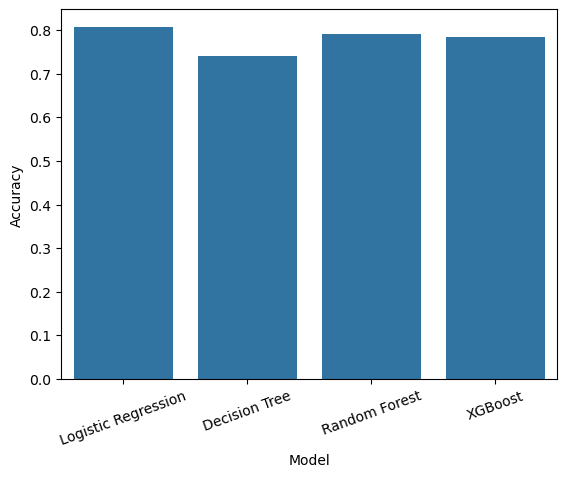

In [928]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(
    x="Model",
    y="Accuracy",
    data=results
)

plt.xticks(rotation=20)

plt.show()

In [929]:
import joblib


In [930]:
joblib.dump(
    lr,
    "../models/best_model.pkl"
)

['../models/best_model.pkl']

In [931]:
joblib.dump(
    scaler,
    "../models/scaler.pkl"
)

['../models/scaler.pkl']

In [932]:
import os

print(os.listdir("../models"))

['best_model.pkl', 'scaler.pkl']


In [933]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": lr.coef_[0]
})

importance.head()

,Feature,Coefficient
0,SeniorCitizen,0.052901
1,tenure,-1.219639
2,MonthlyCharges,-0.921369
3,TotalCharges,0.497246
4,gender_Male,0.011110
